# SECTION 1: DECLARE THE MODULES

In [1]:
import os
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')




# SECTION 2: Data import and preprocess
#Run this but dont worry if it does not make any sense Jump to SECTION 3 that is related to your HD task.

In [2]:
!pip install wget
import wget

link_to_data = 'https://raw.githubusercontent.com/SIT719/2020-S2/master/data/Week_5_NSL-KDD-Dataset/training_attack_types.txt?raw=true'
DataSet = wget.download(link_to_data)

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=19157d5406a68bc2da2e38e2763afdba106973f2e6384a92c590a22e0b88f5a9
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [3]:
DataSet

'training_attack_types.txt'

In [4]:
header_names = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack_type', 'success_pred']


# Differentiating between nominal, binary, and numeric features

# root_shell is marked as a continuous feature in the kddcup.names
# file, but it is supposed to be a binary feature according to the
# dataset documentation

# training_attack_types.txt maps each of the 22 different attacks to 1 of 4 categories
# file obtained from http://kdd.ics.uci.edu/databases/kddcup99/training_attack_types

col_names = np.array(header_names)

nominal_idx = [1, 2, 3]
binary_idx = [6, 11, 13, 14, 20, 21]
numeric_idx = list(set(range(41)).difference(nominal_idx).difference(binary_idx))

nominal_cols = col_names[nominal_idx].tolist()
binary_cols = col_names[binary_idx].tolist()
numeric_cols = col_names[numeric_idx].tolist()

In [5]:
# training_attack_types.txt maps each of the 22 different attacks to 1 of 4 categories
# file obtained from http://kdd.ics.uci.edu/databases/kddcup99/training_attack_types

category = defaultdict(list)
category['benign'].append('normal')

with open(DataSet, 'r') as f:
    for line in f.readlines():
        attack, cat = line.strip().split(' ')
        category[cat].append(attack)

attack_mapping = dict((v,k) for k in category for v in category[k])

In [6]:
attack_mapping

{'normal': 'benign',
 'apache2': 'dos',
 'back': 'dos',
 'mailbomb': 'dos',
 'processtable': 'dos',
 'snmpgetattack': 'dos',
 'teardrop': 'dos',
 'smurf': 'dos',
 'land': 'dos',
 'neptune': 'dos',
 'pod': 'dos',
 'udpstorm': 'dos',
 'ps': 'u2r',
 'buffer_overflow': 'u2r',
 'perl': 'u2r',
 'rootkit': 'u2r',
 'loadmodule': 'u2r',
 'xterm': 'u2r',
 'sqlattack': 'u2r',
 'httptunnel': 'u2r',
 'ftp_write': 'r2l',
 'guess_passwd': 'r2l',
 'snmpguess': 'r2l',
 'imap': 'r2l',
 'spy': 'r2l',
 'warezclient': 'r2l',
 'warezmaster': 'r2l',
 'multihop': 'r2l',
 'phf': 'r2l',
 'named': 'r2l',
 'sendmail': 'r2l',
 'xlock': 'r2l',
 'xsnoop': 'r2l',
 'worm': 'probe',
 'nmap': 'probe',
 'ipsweep': 'probe',
 'portsweep': 'probe',
 'satan': 'probe',
 'mscan': 'probe',
 'saint': 'probe'}

In [7]:
#Processing Training Data

train_file='https://raw.githubusercontent.com/SIT719/2020-S2/master/data/Week_5_NSL-KDD-Dataset/KDDTrain%2B.txt'

train_df = pd.read_csv(train_file, names=header_names)

train_df['attack_category'] = train_df['attack_type'] \
                                .map(lambda x: attack_mapping[x])

train_df.drop(['success_pred'], axis=1, inplace=True)


In [8]:
#Processing test Data
test_file='https://raw.githubusercontent.com/SIT719/2020-S2/master/data/Week_5_NSL-KDD-Dataset/KDDTest%2B.txt'

test_df = pd.read_csv(test_file, names=header_names)
test_df['attack_category'] = test_df['attack_type'] \
                                .map(lambda x: attack_mapping[x])
test_df.drop(['success_pred'], axis=1, inplace=True)

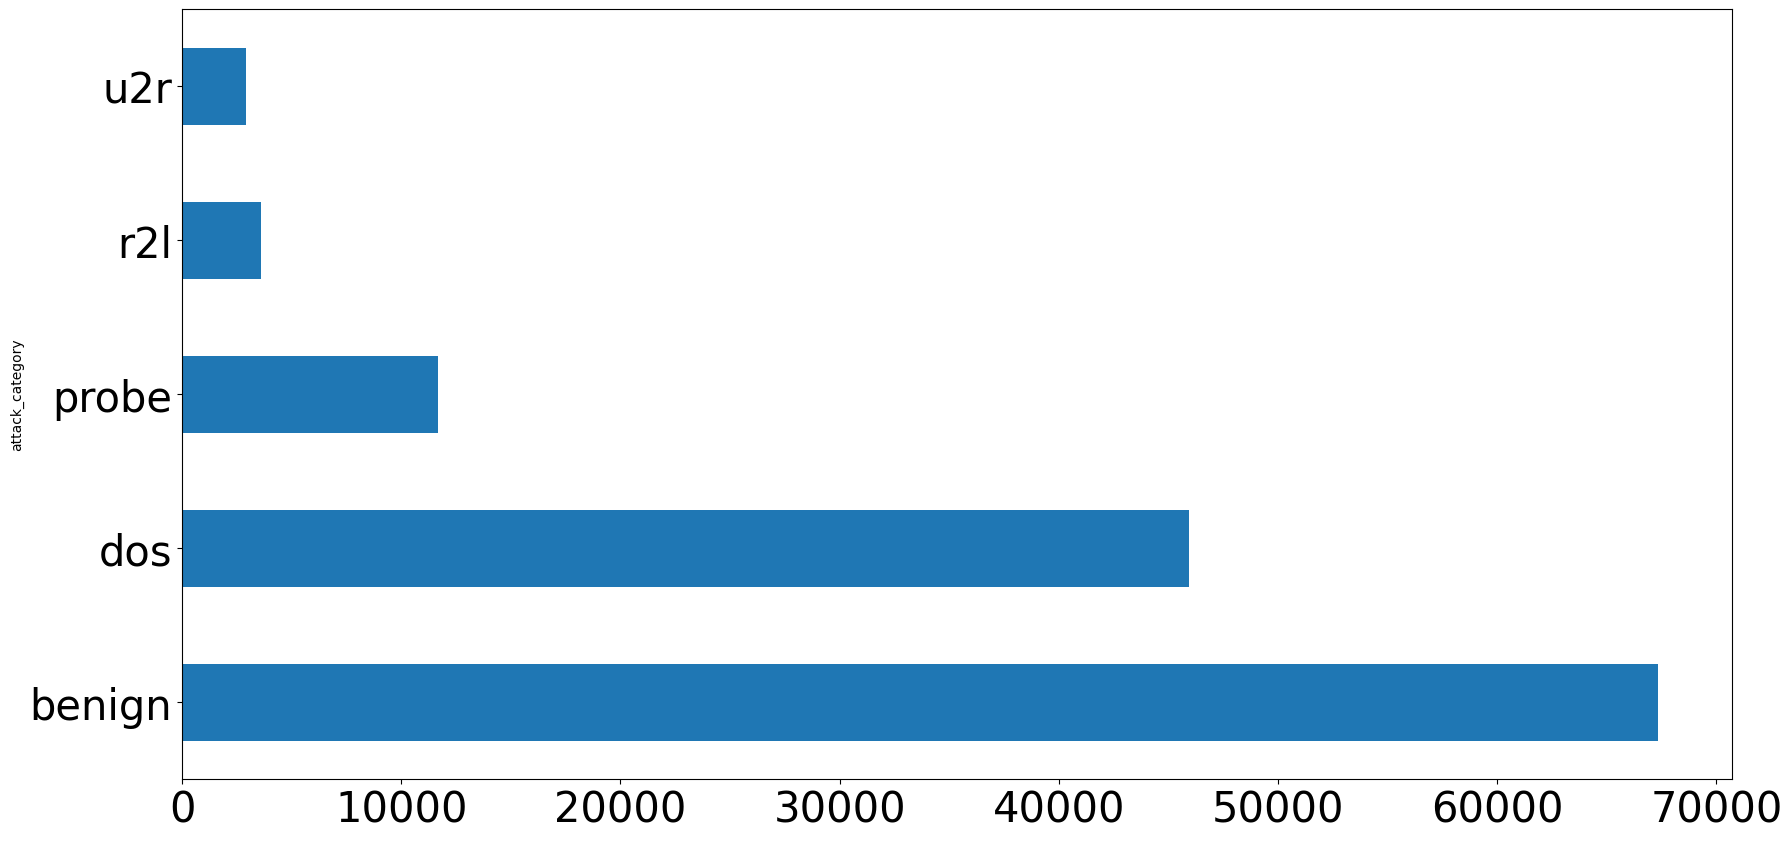

In [9]:
train_attack_types = train_df['attack_type'].value_counts()
train_attack_cats = train_df['attack_category'].value_counts()

test_attack_types = test_df['attack_type'].value_counts()
test_attack_cats = test_df['attack_category'].value_counts()

train_attack_types.plot(kind='barh', figsize=(20,10), fontsize=20)

train_attack_cats.plot(kind='barh', figsize=(20,10), fontsize=30)

train_df[binary_cols].describe().transpose()
train_df.groupby(['su_attempted']).size()
train_df['su_attempted'].replace(2, 0, inplace=True)
test_df['su_attempted'].replace(2, 0, inplace=True)
train_df.groupby(['su_attempted']).size()
train_df.groupby(['num_outbound_cmds']).size()

#Now, that's not a very useful feature - let's drop it from the dataset

train_df.drop('num_outbound_cmds', axis = 1, inplace=True)
test_df.drop('num_outbound_cmds', axis = 1, inplace=True)
numeric_cols.remove('num_outbound_cmds')



#Data Preparation

train_Y = train_df['attack_category']
train_x_raw = train_df.drop(['attack_category','attack_type'], axis=1)
test_Y = test_df['attack_category']
test_x_raw = test_df.drop(['attack_category','attack_type'], axis=1)


combined_df_raw = pd.concat([train_x_raw, test_x_raw])
combined_df = pd.get_dummies(combined_df_raw, columns=nominal_cols, drop_first=True)

train_x = combined_df[:len(train_x_raw)]
test_x = combined_df[len(train_x_raw):]

# Store dummy variable feature names
dummy_variables = list(set(train_x)-set(combined_df_raw))

#execute the commands in console
train_x.describe()
train_x['duration'].describe()
# Experimenting with StandardScaler on the single 'duration' feature
from sklearn.preprocessing import StandardScaler

durations = train_x['duration'].values.reshape(-1, 1)
standard_scaler = StandardScaler().fit(durations)
scaled_durations = standard_scaler.transform(durations)
pd.Series(scaled_durations.flatten()).describe()

# Experimenting with MinMaxScaler on the single 'duration' feature
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler().fit(durations)
min_max_scaled_durations = min_max_scaler.transform(durations)
pd.Series(min_max_scaled_durations.flatten()).describe()

# Experimenting with RobustScaler on the single 'duration' feature
from sklearn.preprocessing import RobustScaler

min_max_scaler = RobustScaler().fit(durations)
robust_scaled_durations = min_max_scaler.transform(durations)
pd.Series(robust_scaled_durations.flatten()).describe()

# Experimenting with MaxAbsScaler on the single 'duration' feature
from sklearn.preprocessing import MaxAbsScaler

max_Abs_scaler = MaxAbsScaler().fit(durations)
robust_scaled_durations = max_Abs_scaler.transform(durations)
pd.Series(robust_scaled_durations.flatten()).describe()

# Let's proceed with StandardScaler- Apply to all the numeric columns

standard_scaler = StandardScaler().fit(train_x[numeric_cols])

train_x[numeric_cols] = \
    standard_scaler.transform(train_x[numeric_cols])

test_x[numeric_cols] = \
    standard_scaler.transform(test_x[numeric_cols])

train_x.describe()



train_Y_bin = train_Y.apply(lambda x: 0 if x is 'benign' else 1)
test_Y_bin = test_Y.apply(lambda x: 0 if x is 'benign' else 1)


# SECTION 3: Multi class classification
#This is the section where you have to add other algorithms, tune algorithms and visualize to compare and analyze algorithms

In [10]:
# 5-class classification version
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, zero_one_loss

classifier = DecisionTreeClassifier(random_state=17)
classifier.fit(train_x, train_Y)

pred_y = classifier.predict(test_x)

results = confusion_matrix(test_Y, pred_y)
error = zero_one_loss(test_Y, pred_y)

print(results)
print(error)


[[9365   56  289    1    0]
 [1541 5998   97    0    0]
 [ 677  220 1526    0    0]
 [2278    1   14  277    4]
 [ 175    0    5    5   15]]
0.2378903477643719


In [11]:
# Model 1: Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    zero_one_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Original sample code
classifier = DecisionTreeClassifier(random_state=17)
classifier.fit(train_x, train_Y)

pred_y = classifier.predict(test_x)

results = confusion_matrix(test_Y, pred_y)
error = zero_one_loss(test_Y, pred_y)

print("Confusion Matrix:")
print(results)
print("\nError Rate:")
print(error)

# Extended evaluation
accuracy = accuracy_score(test_Y, pred_y)
precision = precision_score(test_Y, pred_y, average='weighted', zero_division=0)
recall = recall_score(test_Y, pred_y, average='weighted', zero_division=0)
f1 = f1_score(test_Y, pred_y, average='weighted', zero_division=0)

print("\nAccuracy:", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall:", round(recall * 100, 2), "%")
print("F1 Score:", round(f1 * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(test_Y, pred_y, zero_division=0))

Confusion Matrix:
[[9365   56  289    1    0]
 [1541 5998   97    0    0]
 [ 677  220 1526    0    0]
 [2278    1   14  277    4]
 [ 175    0    5    5   15]]

Error Rate:
0.2378903477643719

Accuracy: 76.21 %
Precision: 81.49 %
Recall: 76.21 %
F1 Score: 73.05 %

Classification Report:
              precision    recall  f1-score   support

      benign       0.67      0.96      0.79      9711
         dos       0.96      0.79      0.86      7636
       probe       0.79      0.63      0.70      2423
         r2l       0.98      0.11      0.19      2574
         u2r       0.79      0.07      0.14       200

    accuracy                           0.76     22544
   macro avg       0.84      0.51      0.54     22544
weighted avg       0.81      0.76      0.73     22544



In [12]:
# Model 2: Random Forest
from sklearn.ensemble import RandomForestClassifier

# Train model
classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=17,
    n_jobs=-1
)
classifier.fit(train_x, train_Y)

# Predict
pred_y = classifier.predict(test_x)

# Original-style outputs
results = confusion_matrix(test_Y, pred_y)
error = zero_one_loss(test_Y, pred_y)

print("Confusion Matrix:")
print(results)
print("\nError Rate:")
print(error)

# Extended evaluation
accuracy = accuracy_score(test_Y, pred_y)
precision = precision_score(test_Y, pred_y, average='weighted', zero_division=0)
recall = recall_score(test_Y, pred_y, average='weighted', zero_division=0)
f1 = f1_score(test_Y, pred_y, average='weighted', zero_division=0)

print("\nAccuracy:", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall:", round(recall * 100, 2), "%")
print("F1 Score:", round(f1 * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(test_Y, pred_y, zero_division=0))

Confusion Matrix:
[[9460   67  183    0    1]
 [1887 5668   81    0    0]
 [ 796  163 1464    0    0]
 [2437    0    1  135    1]
 [ 196    0    1    2    1]]

Error Rate:
0.2579843860894251

Accuracy: 74.2 %
Precision: 80.77 %
Recall: 74.2 %
F1 Score: 70.38 %

Classification Report:
              precision    recall  f1-score   support

      benign       0.64      0.97      0.77      9711
         dos       0.96      0.74      0.84      7636
       probe       0.85      0.60      0.71      2423
         r2l       0.99      0.05      0.10      2574
         u2r       0.33      0.01      0.01       200

    accuracy                           0.74     22544
   macro avg       0.75      0.48      0.48     22544
weighted avg       0.81      0.74      0.70     22544



In [13]:
# Model 3: K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier

# Train model
classifier = KNeighborsClassifier(n_neighbors=5)
classifier.fit(train_x, train_Y)

# Predict
pred_y = classifier.predict(test_x)

# Original-style outputs
results = confusion_matrix(test_Y, pred_y)
error = zero_one_loss(test_Y, pred_y)

print("Confusion Matrix:")
print(results)
print("\nError Rate:")
print(error)

# Extended evaluation
accuracy = accuracy_score(test_Y, pred_y)
precision = precision_score(test_Y, pred_y, average='weighted', zero_division=0)
recall = recall_score(test_Y, pred_y, average='weighted', zero_division=0)
f1 = f1_score(test_Y, pred_y, average='weighted', zero_division=0)

print("\nAccuracy:", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall:", round(recall * 100, 2), "%")
print("F1 Score:", round(f1 * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(test_Y, pred_y, zero_division=0))

Confusion Matrix:
[[9444   54  207    5    1]
 [1630 5925   81    0    0]
 [ 614  180 1629    0    0]
 [2362    2   40  170    0]
 [ 170    0   17    4    9]]

Error Rate:
0.23806777856635908

Accuracy: 76.19 %
Precision: 81.69 %
Recall: 76.19 %
F1 Score: 72.54 %

Classification Report:
              precision    recall  f1-score   support

      benign       0.66      0.97      0.79      9711
         dos       0.96      0.78      0.86      7636
       probe       0.83      0.67      0.74      2423
         r2l       0.95      0.07      0.12      2574
         u2r       0.90      0.04      0.09       200

    accuracy                           0.76     22544
   macro avg       0.86      0.51      0.52     22544
weighted avg       0.82      0.76      0.73     22544



In [14]:
# Model 4: Logistic Regression
from sklearn.linear_model import LogisticRegression

# Train model
classifier = LogisticRegression(max_iter=2000, random_state=17)
classifier.fit(train_x, train_Y)

# Predict
pred_y = classifier.predict(test_x)

# Original-style outputs
results = confusion_matrix(test_Y, pred_y)
error = zero_one_loss(test_Y, pred_y)

print("Confusion Matrix:")
print(results)
print("\nError Rate:")
print(error)

# Extended evaluation
accuracy = accuracy_score(test_Y, pred_y)
precision = precision_score(test_Y, pred_y, average='weighted', zero_division=0)
recall = recall_score(test_Y, pred_y, average='weighted', zero_division=0)
f1 = f1_score(test_Y, pred_y, average='weighted', zero_division=0)

print("\nAccuracy:", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall:", round(recall * 100, 2), "%")
print("F1 Score:", round(f1 * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(test_Y, pred_y, zero_division=0))

Confusion Matrix:
[[9004  302  401    2    2]
 [1690 5937    9    0    0]
 [ 535  110 1753   25    0]
 [2526    3    1   44    0]
 [ 182    4    0    2   12]]

Error Rate:
0.25700851667849534

Accuracy: 74.3 %
Precision: 75.82 %
Recall: 74.3 %
F1 Score: 70.24 %

Classification Report:
              precision    recall  f1-score   support

      benign       0.65      0.93      0.76      9711
         dos       0.93      0.78      0.85      7636
       probe       0.81      0.72      0.76      2423
         r2l       0.60      0.02      0.03      2574
         u2r       0.86      0.06      0.11       200

    accuracy                           0.74     22544
   macro avg       0.77      0.50      0.50     22544
weighted avg       0.76      0.74      0.70     22544



In [15]:
# Model 5: Support Vector Machine (SVM)
from sklearn.svm import SVC

# Train model
classifier = SVC(kernel='rbf', C=1, gamma='scale', random_state=17)
classifier.fit(train_x, train_Y)

# Predict
pred_y = classifier.predict(test_x)

# Original-style outputs
results = confusion_matrix(test_Y, pred_y)
error = zero_one_loss(test_Y, pred_y)

print("Confusion Matrix:")
print(results)
print("\nError Rate:")
print(error)

# Extended evaluation
accuracy = accuracy_score(test_Y, pred_y)
precision = precision_score(test_Y, pred_y, average='weighted', zero_division=0)
recall = recall_score(test_Y, pred_y, average='weighted', zero_division=0)
f1 = f1_score(test_Y, pred_y, average='weighted', zero_division=0)

print("\nAccuracy:", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall:", round(recall * 100, 2), "%")
print("F1 Score:", round(f1 * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(test_Y, pred_y, zero_division=0))

Confusion Matrix:
[[9462   62  187    0    0]
 [1882 5693   61    0    0]
 [ 836  175 1412    0    0]
 [2318    0    4  252    0]
 [ 177    0   15    3    5]]

Error Rate:
0.2537260468417317

Accuracy: 74.63 %
Precision: 81.5 %
Recall: 74.63 %
F1 Score: 71.33 %

Classification Report:
              precision    recall  f1-score   support

      benign       0.64      0.97      0.78      9711
         dos       0.96      0.75      0.84      7636
       probe       0.84      0.58      0.69      2423
         r2l       0.99      0.10      0.18      2574
         u2r       1.00      0.03      0.05       200

    accuracy                           0.75     22544
   macro avg       0.89      0.49      0.51     22544
weighted avg       0.82      0.75      0.71     22544

